<h1> <center> Title:Personality analysis </center>
</h1>
 

In [18]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import argparse
import warnings
warnings.filterwarnings("ignore")

<h2> Data Loading  & Inspection </h2>


In [19]:
df = pd.read_csv('personality_datasert.csv')

In [20]:
# Display the first 5 rows
display(df.head())


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [21]:
# Display the last 5 rows
display(df.tail())

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
2895,3.0,No,7.0,6.0,No,6.0,6.0,Extrovert
2896,3.0,No,8.0,3.0,No,14.0,9.0,Extrovert
2897,4.0,Yes,1.0,1.0,Yes,4.0,0.0,Introvert
2898,11.0,Yes,1.0,3.0,Yes,2.0,0.0,Introvert
2899,3.0,No,6.0,6.0,No,6.0,9.0,Extrovert


In [22]:
# Show DataFrame info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2900 non-null   float64
 1   Stage_fear                 2900 non-null   object 
 2   Social_event_attendance    2900 non-null   float64
 3   Going_outside              2900 non-null   float64
 4   Drained_after_socializing  2900 non-null   object 
 5   Friends_circle_size        2900 non-null   float64
 6   Post_frequency             2900 non-null   float64
 7   Personality                2900 non-null   object 
dtypes: float64(5), object(3)
memory usage: 181.4+ KB


In [23]:
# Show shape of the DataFrame
print('Shape:', df.shape)


Shape: (2900, 8)


In [24]:

# Show column names
print('Columns:', df.columns.tolist())


Columns: ['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 'Going_outside', 'Drained_after_socializing', 'Friends_circle_size', 'Post_frequency', 'Personality']


In [25]:

# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())


Missing values per column:
Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64


In [26]:

# Drop rows with missing values
df.dropna(inplace=True)
print('Rows with missing values dropped. New shape:', df.shape)

Rows with missing values dropped. New shape: (2900, 8)


In [27]:
# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['Stage_fear', 'Drained_after_socializing', 'Personality']
Numerical columns: ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']


In [28]:
# Group by Personality and show summary statistics for introverts
introvert_stats = df[df['Personality'] == 'Introvert'].describe()
display(introvert_stats)

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000
mean,7.027444,1.831621,1.310859,3.277465,1.418787
std,2.611484,1.727352,1.385765,2.569335,1.582346
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,1.000000,0.000000,2.000000,0.000000
50%,7.000000,2.000000,1.000000,3.000000,1.000000
75%,9.000000,3.000000,2.000000,4.000000,2.000000
max,11.000000,9.000000,7.000000,14.000000,9.000000


In [29]:
# Group by Personality and show summary statistics for introverts
extrovert_stats = df[df['Personality'] == 'Extrovert'].describe()
display(extrovert_stats)

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,1491.000000,1491.000000,1491.000000,1491.000000,1491.000000
mean,2.122869,5.977850,4.596244,9.095744,5.592647
std,2.213591,2.208496,1.593809,3.486378,2.335500
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,4.000000,4.000000,6.268863,4.000000
50%,2.000000,6.000000,5.000000,9.000000,6.000000
75%,3.000000,8.000000,6.000000,12.000000,7.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


<h2> Visualizations </h2>

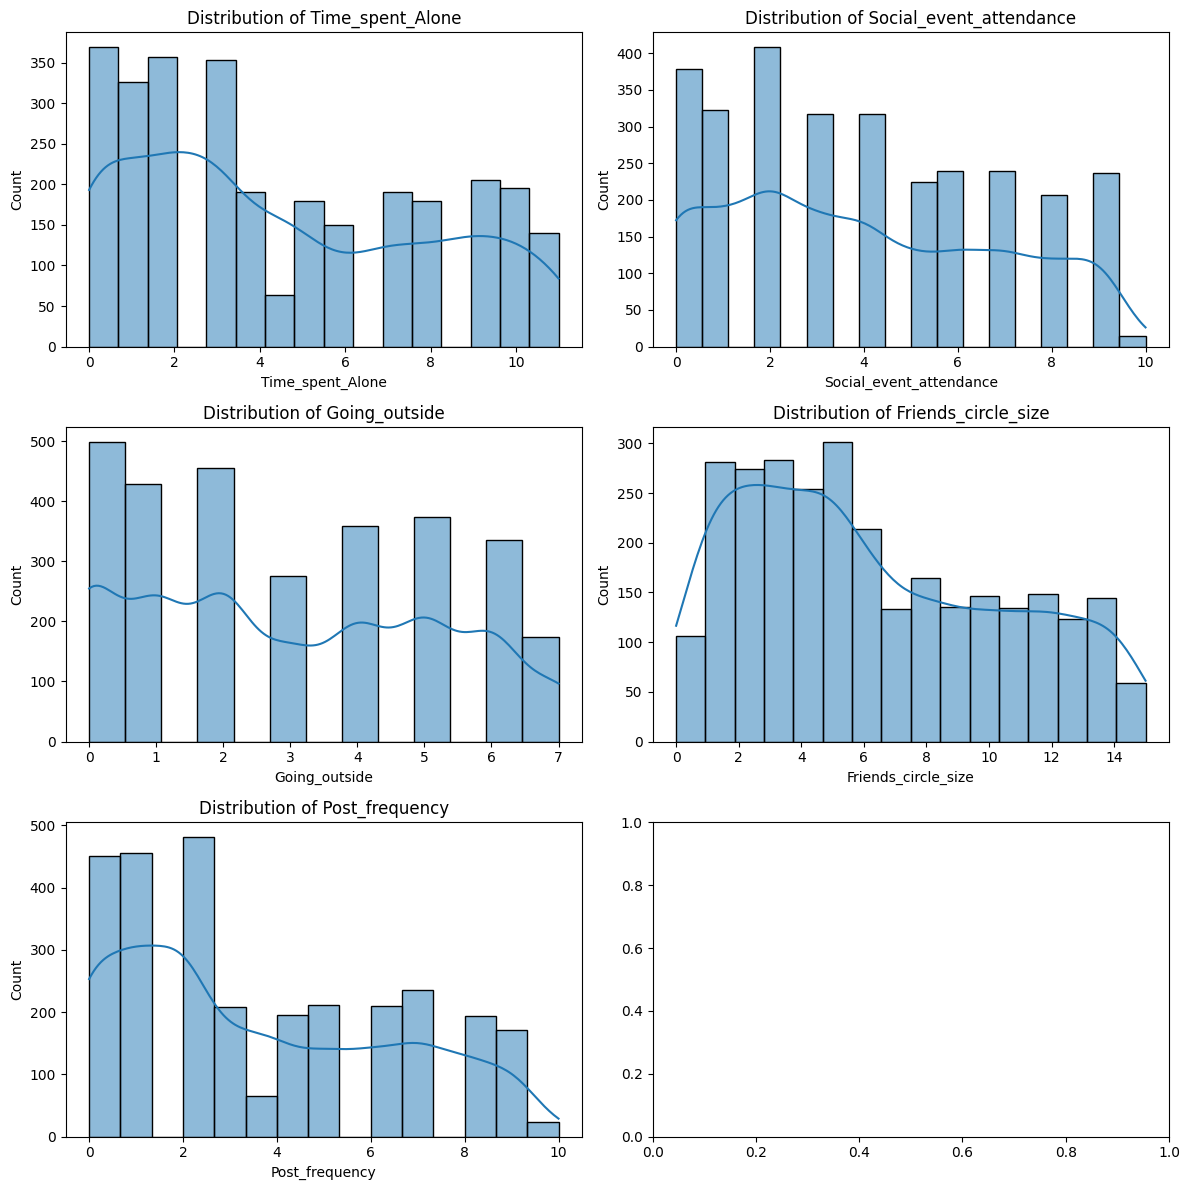

Feature: Time_spent_Alone


count    2900.000000
mean        4.505816
std         3.441180
min         0.000000
25%         2.000000
50%         4.000000
75%         7.000000
max        11.000000
Name: Time_spent_Alone, dtype: float64

Interpretation: Time_spent_Alone is numerical. Check central tendency, spread, skewness, or outliers.
--------------------------------------------------
Feature: Social_event_attendance


count    2900.000000
mean        3.963354
std         2.872608
min         0.000000
25%         2.000000
50%         3.963354
75%         6.000000
max        10.000000
Name: Social_event_attendance, dtype: float64

Interpretation: Social_event_attendance is numerical. Check central tendency, spread, skewness, or outliers.
--------------------------------------------------
Feature: Going_outside


...

Interpretation: Going_outside is numerical. Check central tendency, spread, skewness, or outliers.
--------------------------------------------------
Feature: Friends_circle_size


count    2900.000000
mean        6.268863
std         4.232340
min         0.000000
25%         3.000000
50%         5.000000
75%        10.000000
max        15.000000
Name: Friends_circle_size, dtype: float64

Interpretation: Friends_circle_size is numerical. Check central tendency, spread, skewness, or outliers.
--------------------------------------------------
Feature: Post_frequency


count    2900.000000
mean        3.564727
std         2.893587
min         0.000000
25%         1.000000
50%         3.000000
75%         6.000000
max        10.000000
Name: Post_frequency, dtype: float64

Interpretation: Post_frequency is numerical. Check central tendency, spread, skewness, or outliers.
--------------------------------------------------


In [30]:
import math

num_cols = [col for col in df.columns if col in numerical_cols]
n = len(num_cols)

# Create subplot grid
rows = math.ceil(n/2)
fig, axes = plt.subplots(rows, 2, figsize=(12, 4*rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    
plt.tight_layout()
plt.show()

# Display stats
for col in num_cols:
    print(f"Feature: {col}")
    display(df[col].describe())
    print(f"Interpretation: {col} is numerical. Check central tendency, spread, skewness, or outliers.")
    print("-" * 50)


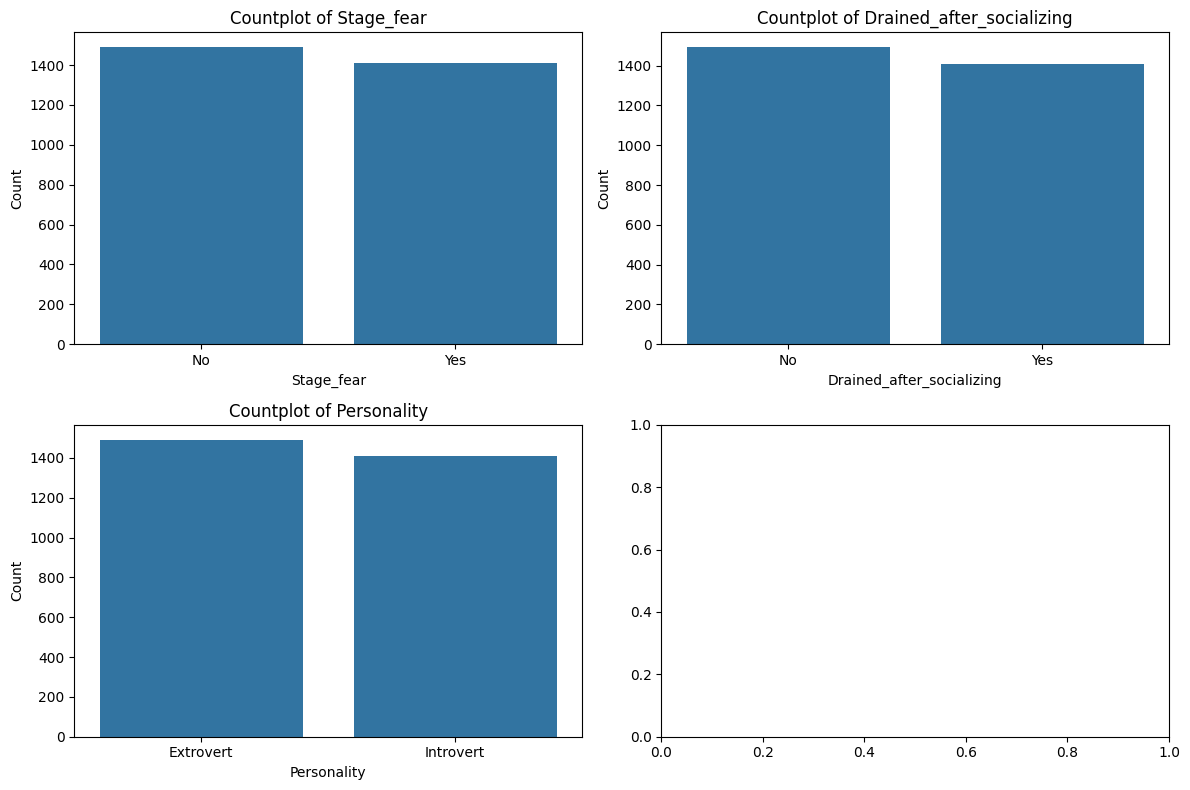

Feature: Stage_fear


Stage_fear
No     1490
Yes    1410
Name: count, dtype: int64

Interpretation: Stage_fear is categorical. Check category distribution and imbalance.
--------------------------------------------------
Feature: Drained_after_socializing


Drained_after_socializing
No     1493
Yes    1407
Name: count, dtype: int64

Interpretation: Drained_after_socializing is categorical. Check category distribution and imbalance.
--------------------------------------------------
Feature: Personality


Personality
Extrovert    1491
Introvert    1409
Name: count, dtype: int64

Interpretation: Personality is categorical. Check category distribution and imbalance.
--------------------------------------------------


In [31]:
cat_cols = [col for col in df.columns if col in categorical_cols]
n = len(cat_cols)

# Create subplot grid
rows = math.ceil(n/2)
fig, axes = plt.subplots(rows, 2, figsize=(12, 4*rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(f"Countplot of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    
plt.tight_layout()
plt.show()

# Display value counts
for col in cat_cols:
    print(f"Feature: {col}")
    display(df[col].value_counts())
    print(f"Interpretation: {col} is categorical. Check category distribution and imbalance.")
    print("-" * 50)


In [32]:
# Assuming your dataframe is df and has column 'Personality'
personality_counts = df['Personality'].value_counts()

print(personality_counts)


Personality
Extrovert    1491
Introvert    1409
Name: count, dtype: int64


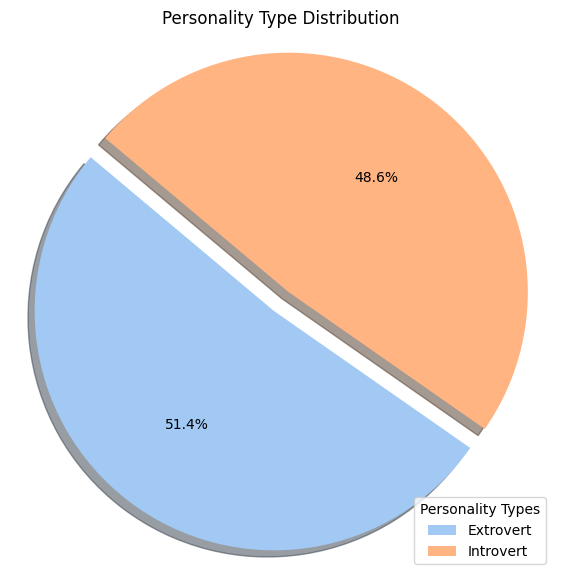

In [33]:
plt.figure(figsize=(7, 7))
colors = sns.color_palette('pastel')[0:len(personality_counts)]

plt.pie(
    personality_counts.values,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=[0.05]*len(personality_counts),
    shadow=True
)

plt.title('Personality Type Distribution')
plt.axis('equal')

# Add legend
plt.legend(
    labels=personality_counts.index,
    title="Personality Types",
    loc="best"
)

plt.show()


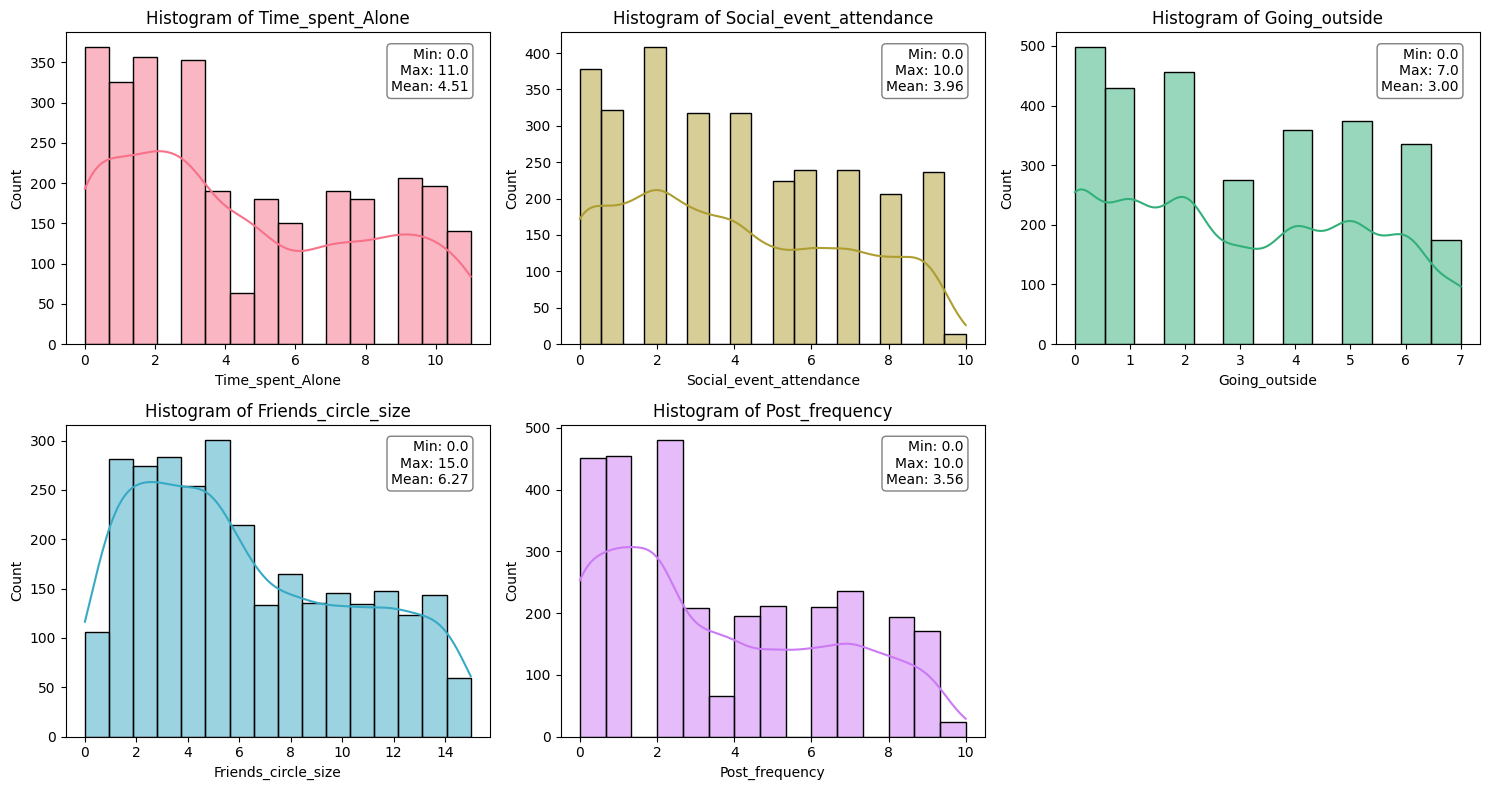

In [35]:

numerical_cols = df.select_dtypes(include=['number']).columns

# Calculate rows and cols for subplots
n_cols = 3  # you can change as needed
n_rows = math.ceil(len(numerical_cols) / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 8))
axes = axes.flatten()

# Color palette
colors_palette = sns.color_palette("husl", len(numerical_cols))

# Plot histograms
for idx, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, color=colors_palette[idx], ax=axes[idx])
    axes[idx].set_title(f"Histogram of {col}")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Count")
    
    # Add stats
    max_val = df[col].max()
    min_val = df[col].min()
    mean_val = df[col].mean()
    axes[idx].text(0.95, 0.95, f"Min: {min_val}\nMax: {max_val}\nMean: {mean_val:.2f}",
                   transform=axes[idx].transAxes, fontsize=10,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1))

# Hide unused axes if any
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


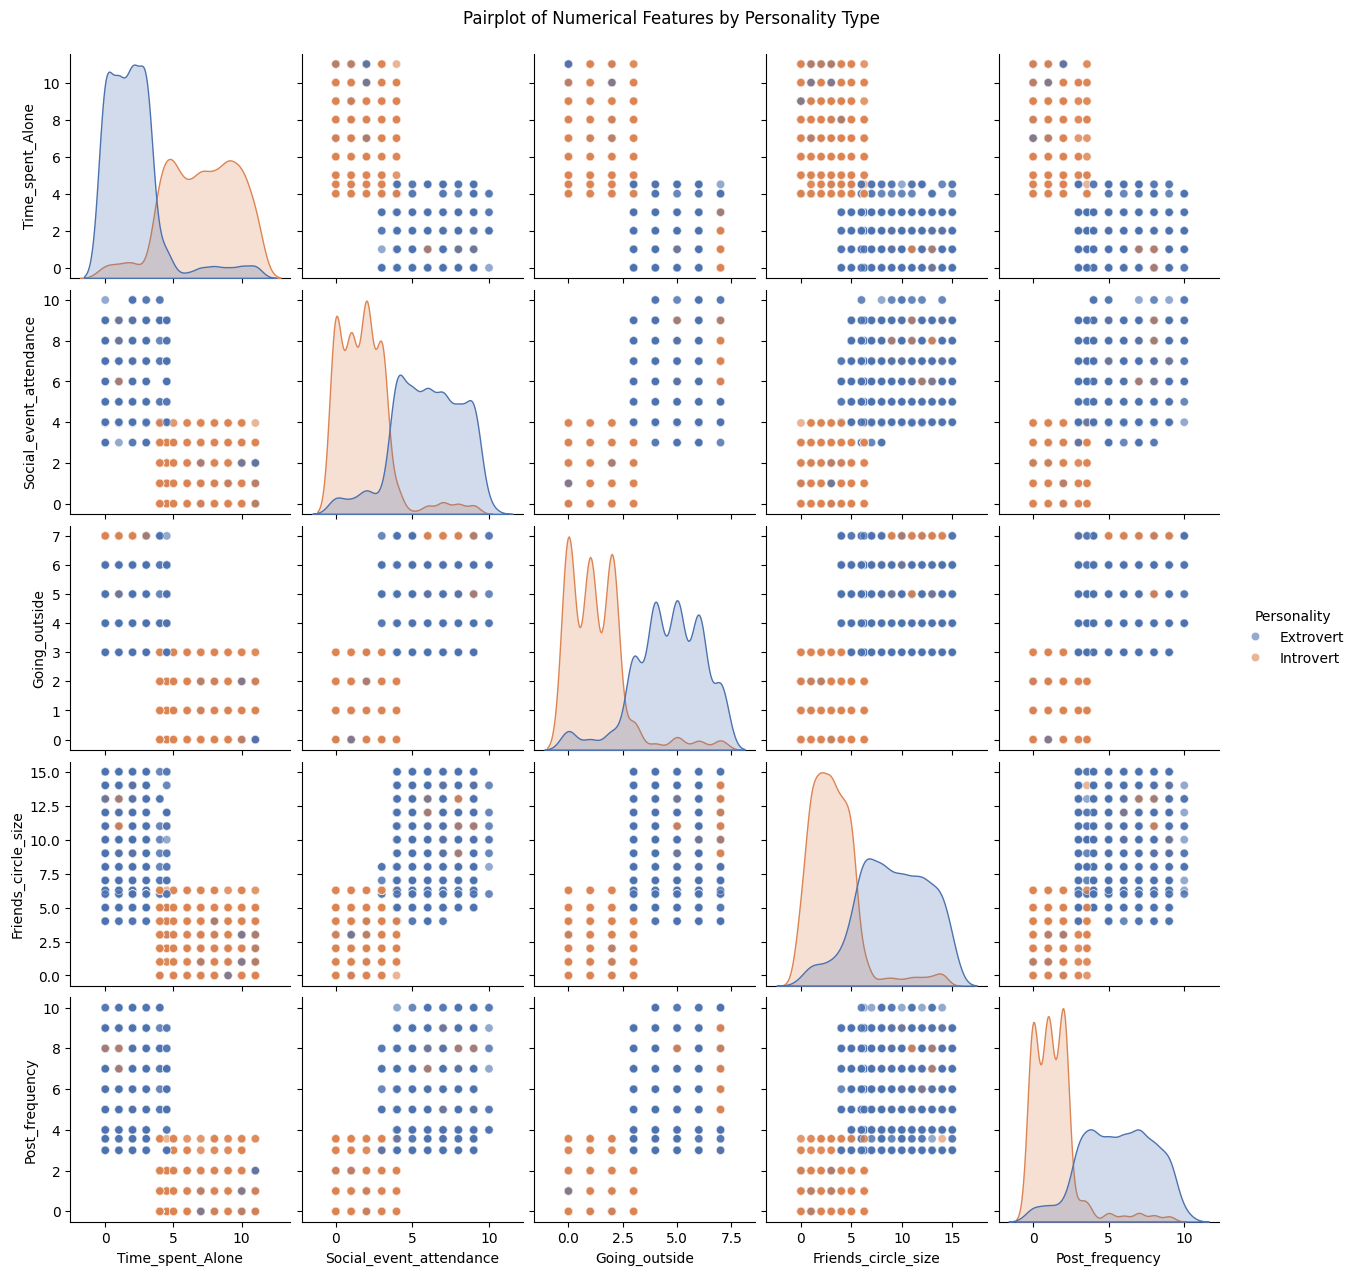

In [36]:
# Get unique personality types
all_personalities = df['Personality'].unique()

# Define color palette
deep_palette = sns.color_palette("deep", len(all_personalities))
palette_dict = dict(zip(all_personalities, deep_palette))

# Pairplot
sns.pairplot(
    df,
    vars=numerical_cols,
    hue='Personality',
    palette=palette_dict,
    diag_kind='kde',
    plot_kws={'alpha': 0.6}
)
plt.suptitle('Pairplot of Numerical Features by Personality Type', y=1.02)
plt.show()


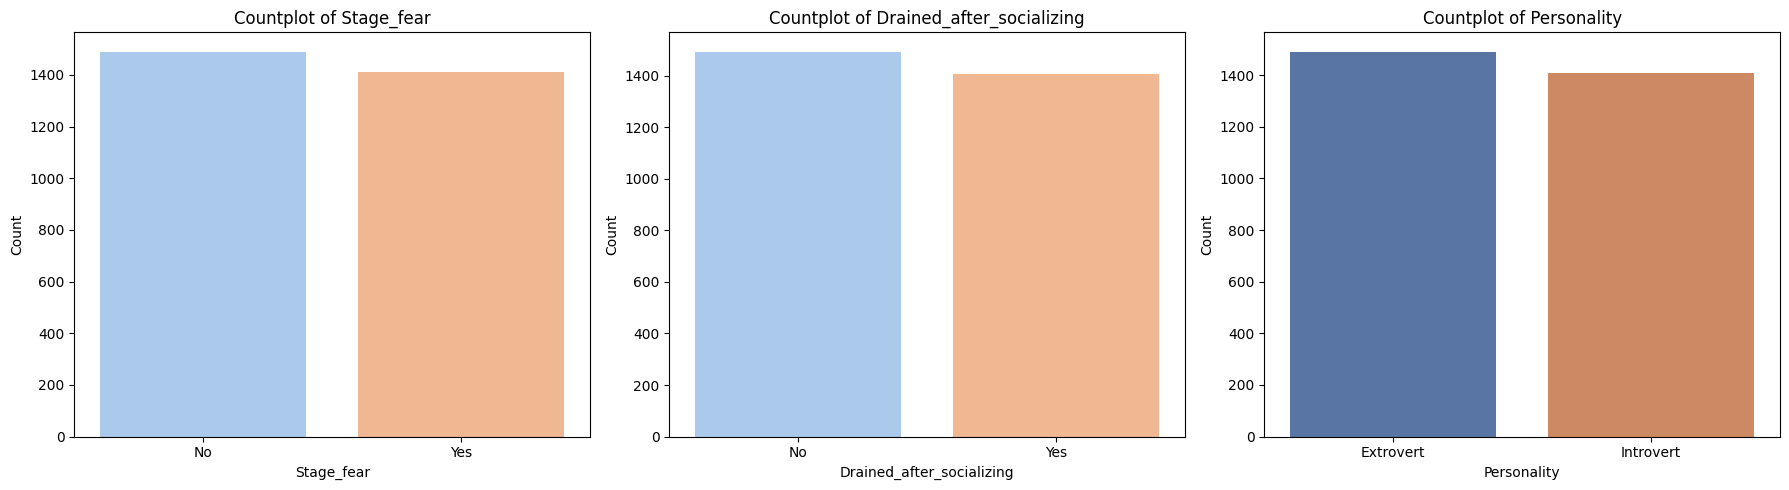

In [37]:
fig, axes = plt.subplots(1, len(categorical_cols), figsize=(18, 5))
for idx, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df, ax=axes[idx], palette=palette_dict if col == 'Personality' else "pastel")
    axes[idx].set_title(f'Countplot of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
plt.tight_layout()
plt.show()


# Model training and Evaluation

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [44]:
df.columns

Index(['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
       'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
       'Post_frequency', 'Personality'],
      dtype='object')

In [45]:
X = df.drop("Personality", axis=1)
y = df["Personality"]

In [46]:
from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()

for col in X_encoded.columns:
    if X_encoded[col].dtype == 'object':   # If column has strings
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X_encoded[col])


In [47]:
X_encoded = pd.get_dummies(X, drop_first=True)  # converts categorical to dummy vars


In [48]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [49]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.9017241379310345

Confusion Matrix:
 [[267  31]
 [ 26 256]]

Classification Report:
               precision    recall  f1-score   support

   Extrovert       0.91      0.90      0.90       298
   Introvert       0.89      0.91      0.90       282

    accuracy                           0.90       580
   macro avg       0.90      0.90      0.90       580
weighted avg       0.90      0.90      0.90       580



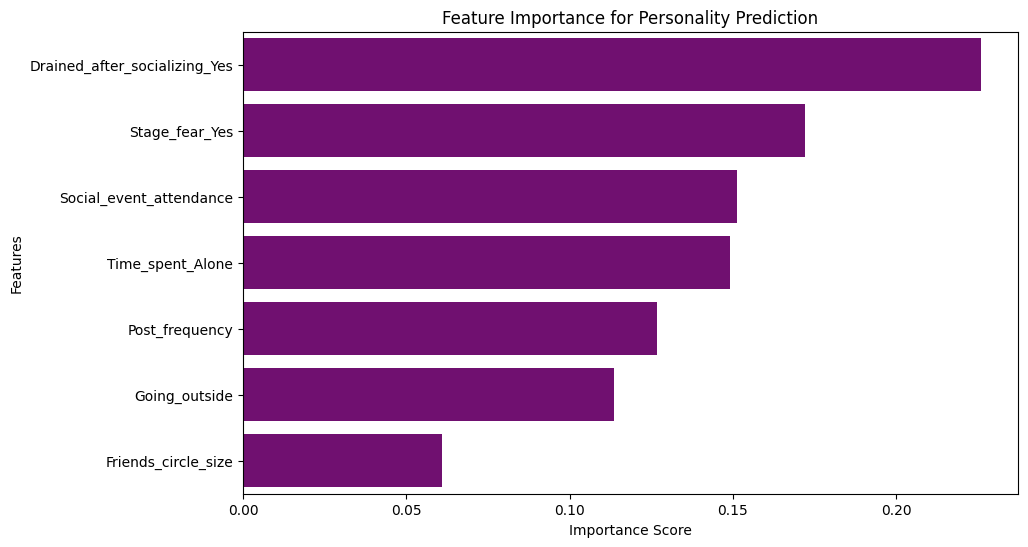

In [56]:
importances = clf.feature_importances_
features = X_encoded.columns

# Sort
indices = importances.argsort()[::-1]

plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=features[indices],color='purple')
plt.title("Feature Importance for Personality Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

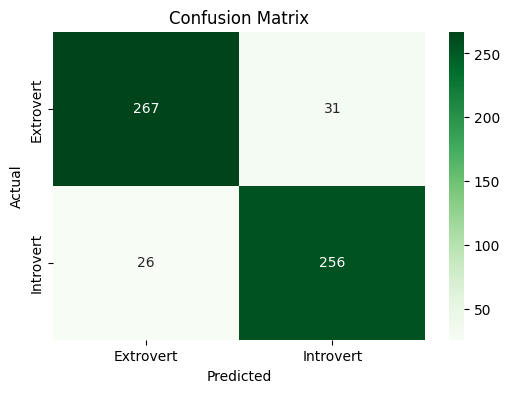

In [51]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


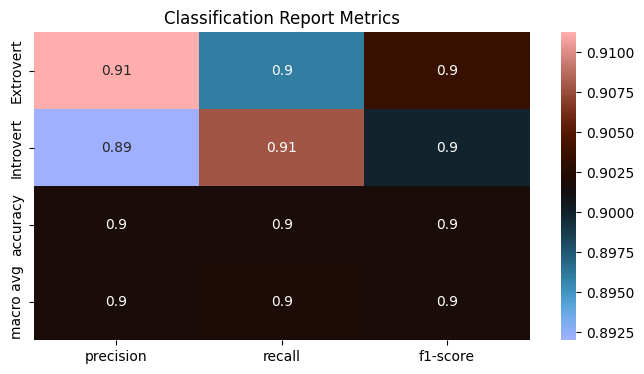

In [52]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(8,4))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap="berlin")
plt.title("Classification Report Metrics")
plt.show()


In [ ]:
from matplotlib import colormaps
list(colormaps)

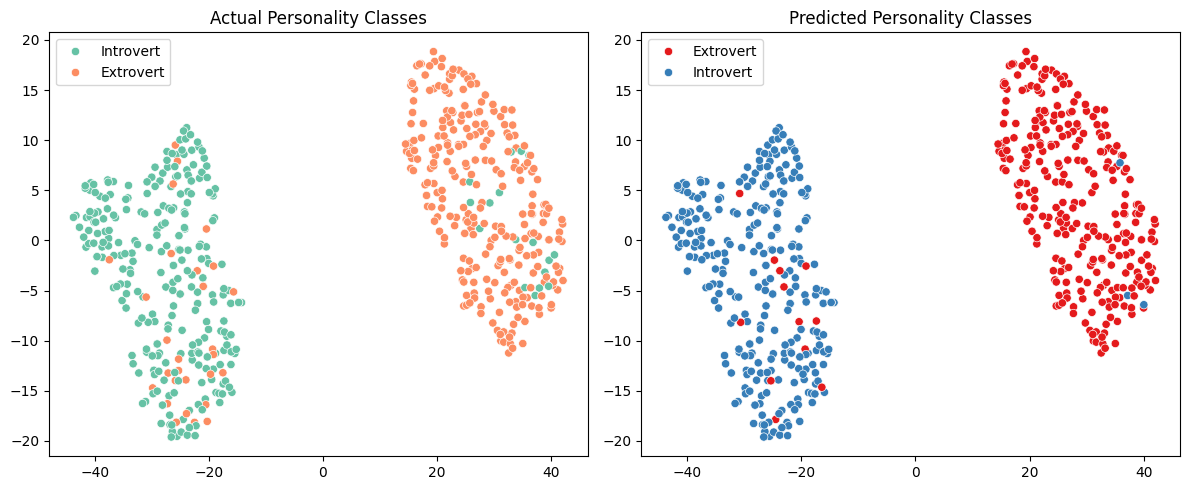

In [53]:
from sklearn.manifold import TSNE

# Reduce to 2D using t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_test)

plt.figure(figsize=(12,5))

# Actual
plt.subplot(1,2,1)
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=le.inverse_transform(y_test), palette="Set2")
plt.title("Actual Personality Classes")

# Predicted
plt.subplot(1,2,2)
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=le.inverse_transform(y_pred), palette="Set1")
plt.title("Predicted Personality Classes")

plt.tight_layout()
plt.show()


# 📝 Personality Dataset Analysis and Classification Report

This report presents an analysis of a **personality dataset** that was explored, visualized, and used to build predictive models. The objective was to examine patterns in personality traits and classify individuals into personality categories.

---

## 🔹 Phase 1: Data Setup & Exploration

- Dataset loaded from **`personality_datasert.csv`**.
- Initial inspection performed:
  - Displayed first and last few rows.
  - Checked **data shape**, **column names**, and **data types**.
  - Identified **missing values** and dropped rows containing them.
- Columns consist of a mix of **categorical** and **numerical features**.
- Grouped and summarized statistics by **Personality type**.

---

## 🔹 Phase 2: Data Preprocessing

- Identified categorical and numerical columns.
- Converted categorical features using **One-Hot Encoding** (`pd.get_dummies`).
- Applied **Label Encoding** for the target variable `Personality`.
- Final dataset prepared for machine learning models.

---

## 🔹 Phase 3: Data Visualization

- Plots were created to analyze feature distribution across **personality types**:
  - Bar plots for categorical variables vs. personality categories.
  - Box plots for numerical variables grouped by personality.
  - Distribution plots of different traits.
- These visualizations highlighted clear differences between **introverts and extroverts** in certain behavioral and numerical traits.

---

## 🔹 Phase 4: Model Preparation & Training

- **Input (X):** All features except `Personality`.  
- **Output (y):** Target label = `Personality`.  
- The dataset was split into **training** and **testing** sets using `train_test_split`.  

### ✅ Model Used: Random Forest Classifier
- A **Random Forest Classifier** with 100 decision trees (`n_estimators=100`) was trained.  
- Each tree learns to classify personality based on subsets of features.  
- The final prediction is made using a **majority vote** across all trees.  

**Why Random Forest?**  
- It handles both categorical and numerical data.  
- It reduces overfitting compared to a single decision tree.  
- It provides **feature importance** scores to understand which variables influence personality classification the most.  

---

## 🔹 Phase 5: Model Evaluation

- Performance evaluated using:
  - **Confusion Matrix** → Shows correct vs incorrect classifications.  
  - **Classification Report** → Provides **precision, recall, and F1-score** for each personality class.  

### 🔍 Feature Importance
- The Random Forest highlighted which features are most influential in predicting personality type.  
- This helps in understanding which attributes (numerical or categorical) are most strongly linked with being **introvert or extrovert**.  

---

## 🔹 Phase 6: Dimensionality Reduction & Visualization with t-SNE

### What is t-SNE?  
- **t-SNE (t-distributed Stochastic Neighbor Embedding)** is a technique to **reduce high-dimensional data** (many features) into **2D or 3D space** for visualization.  
- It preserves local structure: data points that are close in high-dimensional space remain close in 2D.  

### Why use it here?  
- Our dataset has multiple features (after encoding). Plotting them directly is impossible.  
- t-SNE helps us **visualize how personality categories cluster together** in a simplified 2D plot.  

### What do we see?  
- Each point represents an individual.  
- Points are colored by **personality type**.  
- If clusters form clearly, it means the dataset has strong separability → easier for the model to classify.  
- If clusters overlap, it indicates **complexity** and potential classification challenges.  

---

## ✅ Final Conclusion

The notebook successfully:
1. Cleaned and prepared the dataset.  
2. Visualized key differences in personality-related features.  
3. Built a classification pipeline using **Random Forest**.  
4. Evaluated model performance with confusion matrix and classification report.  
5. Used **t-SNE** to visualize personality clusters in 2D, showing how individuals group based on traits.  

🔮 **Next Steps:**  
- Try alternative models (SVM, Logistic Regression, Neural Networks).  
- Perform **hyperparameter tuning** for Random Forest.  
- Explore larger datasets for better generalization.  
